In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qm import SimulationConfig
from qm.qua import *
import os
import xarray as xr
import json
from quam_libs.components import QuAM
from quam_libs.lib.save_utils import find_numbered_folder
import scipy.optimize


2025-11-25 20:08:21,491 - qm - INFO     - Starting session: 96033ecf-d019-4de9-93ca-83a7c1cb7308


/Users/mohammadkashani/Documents/Qolab/qolab-start/.venv/lib/python3.11/site-packages/qm/results/__init__.py:15: DeprecationWarning: qm.results is deprecated since "1.2.3" and will be removed in "1.3.0". If you need anything from this module, import it directly from `qm` or from `qm.simulate` for simulator-related functionality.
  warnings.warn(


In [3]:
def load_dataset(serial_number, target_filename = "ds", parameters = None):
    """
    Loads a dataset from a file based on the serial number.
    
    Args:
        serial_number: The serial number to search for.
        base_folder: The base directory to search in.
    
    Returns:
        An xarray Dataset if found, None otherwise.
    """
    if not isinstance(serial_number, int):
        raise ValueError("serial_number must be an integer")
        
    base_folder = "/Users/mohammadkashani/Documents/Qolab/qolab-start/data/"
    for subfolder in os.listdir(base_folder):
        if os.path.isdir(os.path.join(base_folder, subfolder)):
            for subfolder_2 in os.listdir(os.path.join(base_folder, subfolder)):
                if '#'+str(serial_number) in os.path.basename(subfolder_2):
                    base_folder = os.path.join(base_folder, subfolder, subfolder_2)
                    break
    print(f"Searching in folder: {base_folder}")
        
    print(f"Loading data from folder: {base_folder}")
    # Look for .nc files in the subfolder
    nc_files = [f for f in os.listdir(base_folder) if f.endswith('.h5')]
    print(nc_files)
    # look for filename.h5
    is_present = target_filename in [file.split('.')[0] for file in nc_files]
    filename = [file for file in nc_files if target_filename == file.split('.')[0]][0] if is_present else None
    json_filename = "data.json"
    
    if nc_files:
        # Assuming there's only one .nc file per folder
        file_path = os.path.join(base_folder, filename)
        json_path = os.path.join(base_folder, json_filename)
        # Open the dataset
        print(f"Loading dataset from file: {file_path}")
        ds = xr.open_dataset(file_path)
        with open(json_path, 'r') as f:
            json_data = json.load(f)
        try:
            machine = QuAM.load(base_folder + "/quam_state/state.json")
        except Exception as e:
            print(f"Error loading machine: {e}")
            machine = None
        qubits = [machine.qubits[qname] for qname in ds.qubit.values]    
        if parameters is not None:
            for param_name, param_value in parameters:
                if param_name != "load_data_id":
                    if param_name in json_data["initial_parameters"]:
                        setattr(parameters, param_name, json_data["initial_parameters"][param_name])
            return ds, machine, json_data, qubits,parameters
        else:
            return ds, machine, json_data, qubits
    else:
        print(f"No .nc file found in folder: {base_folder}")
        return None


# Probelm #2

RB Fitting - Extract the data from dataset 81 to plot randomized
benchmarking (RB) data. Fit the RB curves to extract error probabilities. Which
qubit has the best average error? Which has the best SPAM? Why?

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-12/#81_10a_Single_Qubit_Randomized_Benchmarking_151746
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-12/#81_10a_Single_Qubit_Randomized_Benchmarking_151746
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-12/#81_10a_Single_Qubit_Randomized_Benchmarking_151746/ds.h5


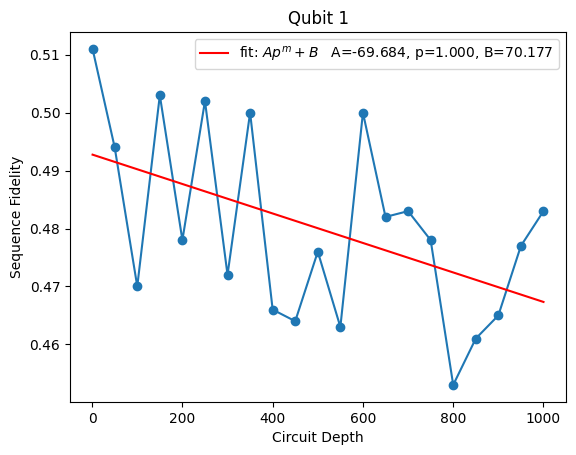

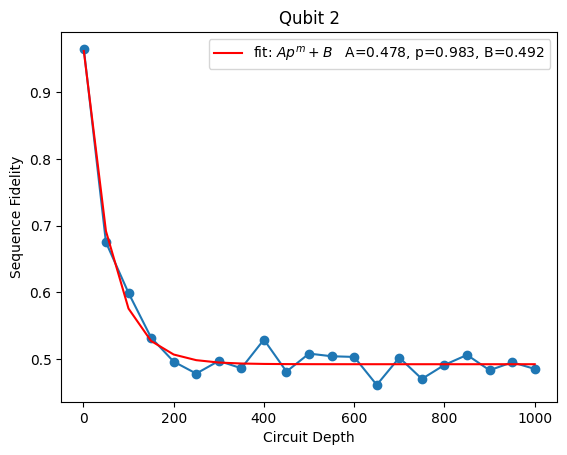

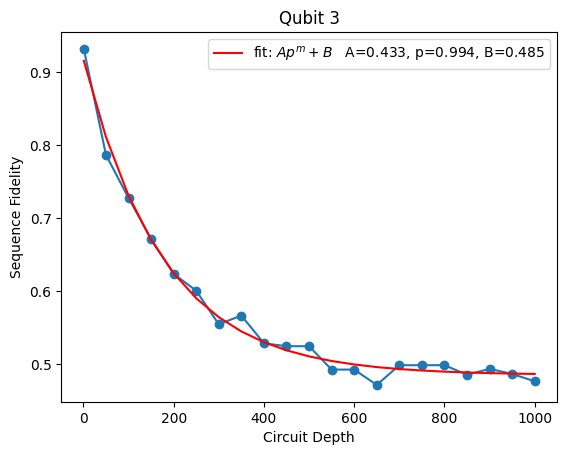

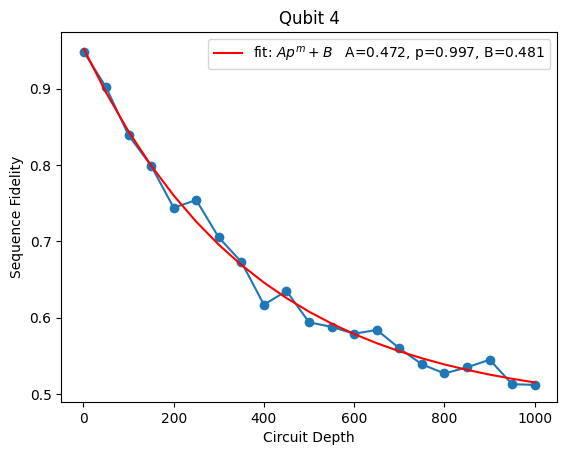

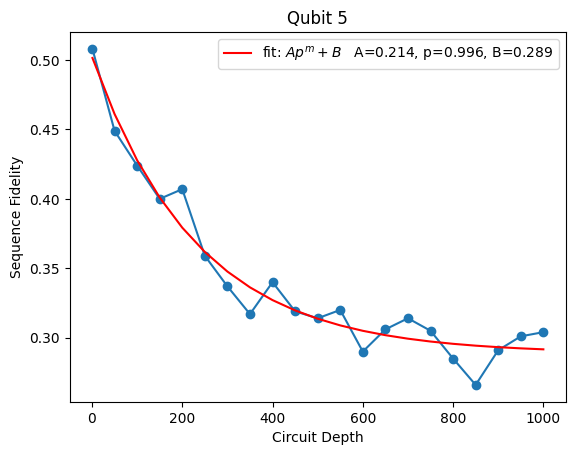

{'Qubit_1': {'A': -69.68406621291237,
             'B': 70.17683955143315,
             'p': 1.0000003651455185},
 'Qubit_2': {'A': 0.4780599921912272,
             'B': 0.4920508413161864,
             'p': 0.9826989603643316},
 'Qubit_3': {'A': 0.4325982048197728,
             'B': 0.48549893080928275,
             'p': 0.9943577497463442},
 'Qubit_4': {'A': 0.47177498086831243,
             'B': 0.48132365225744506,
             'p': 0.9973721927941339},
 'Qubit_5': {'A': 0.21366778973511727,
             'B': 0.28871607546064565,
             'p': 0.9957161759860713}}


In [4]:
import pprint

b = load_dataset(81)


def func(x, a, p, b):
    return a * np.power(p,x) + b


P = {}
for i in range(5):
    x = b[0]["depths"].values
    xdata = 1-np.mean(b[0]["state"].values[i],axis=0)
    popt, pcov = scipy.optimize.curve_fit(func, x,xdata)

    plt.plot(b[0]["depths"].values,xdata,"o-")
    plt.plot(b[0]["depths"].values, func(x, *popt), 'r-',
         label= r'fit: $A p^{m} + B$   A=%5.3f, p=%5.3f, B=%5.3f' % tuple(popt))
    
    plt.xlabel("Circuit Depth")
    plt.ylabel("Sequence Fidelity")
    plt.title(f"Qubit {i+1}")
    plt.legend()
    plt.show()
    P[f"Qubit_{i+1}"] = {'A': popt[0], 'p': popt[1], 'B': popt[2]}
pprint.pprint(P)


Which qubit has the best average error? Which has the best SPAM? Why?

From the fitting the Qubit 4 had the best average error.
``` bash
'Qubit_4': {'p': 0.9973721927941339},
'Qubit_3': {'p': 0.9943577497463442},
'Qubit_2': {'p': 0.9826989603643316},
```

These qubits had the worst Spam error. I don't understand if the question is asking which qubit has the worst spam error in general or amongst the working qubits?
```bash
{
 'Qubit_1': {'A': -69.68406621291237,
             'B': 70.17683955143315,
             'p': 1.0000003651455185},
             
 'Qubit_5': {'A': 0.21366778973511727,
             'B': 0.28871607546064565,
             'p': 0.9957161759860713}}
}
```





## Problem #3
Extract the data from dataset 110 and use your
code from problem 2 to extract the average error. Note this is only on qubit 4.
Compare it the results of problem 2. 

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-13/#110_10a_Single_Qubit_Randomized_Benchmarking_043752
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-13/#110_10a_Single_Qubit_Randomized_Benchmarking_043752
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-13/#110_10a_Single_Qubit_Randomized_Benchmarking_043752/ds.h5


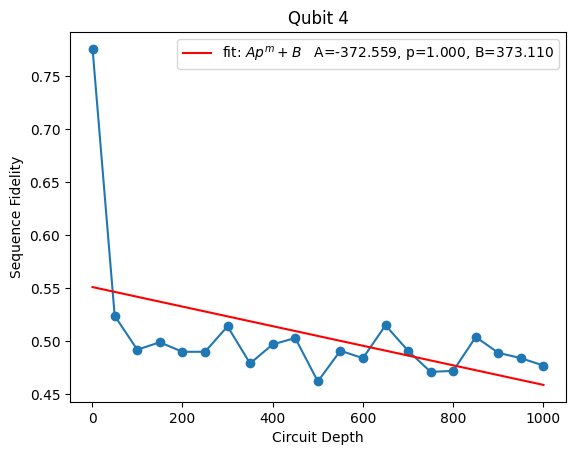

{'Qubit_4': {'A': -372.5589834631924,
             'B': 373.1101746490843,
             'p': 1.0000002481772274}}


In [6]:
b = load_dataset(110)


def func(x, a, p, b):
    return a * np.power(p,x) + b


P = {}
for i in range(1):
    x = b[0]["depths"].values
    xdata = 1-np.mean(b[0]["state"].values[i],axis=0)
    popt, pcov = scipy.optimize.curve_fit(func, x,xdata)

    plt.plot(b[0]["depths"].values,xdata,"o-")
    plt.plot(b[0]["depths"].values, func(x, *popt), 'r-',
         label= r'fit: $A p^{m} + B$   A=%5.3f, p=%5.3f, B=%5.3f' % tuple(popt))
    
    plt.xlabel("Circuit Depth")
    plt.ylabel("Sequence Fidelity")
    plt.title(f"Qubit {4}")
    plt.legend()
    plt.show()
    P[f"Qubit_{4}"] = {'A': popt[0], 'p': popt[1], 'B': popt[2]}
pprint.pprint(P)

### the qubit 4 has gotteb much worse 

## The only line changes is the amplitude of the x180 drag cosine amplitude. from  .08 -> .19

<img src="img/HW3-state-json-difference.png" alt="alt text" style="width:700px;">

### What is the purpose of this variable? 
The probability of the exitation to the excited state relates to the amplitude of the applied pulse which has to be optimized.
 
### What effect would it have on the qubit?
Not properly tuning this parameter will result in no excitation to the proper state.

## Problem #4
In this exercise, you will actually run something
on the Qolab chip. Your token must be properly setup or this will not work. Please
submit your data directory along with the other parts.

a) First, compare the state.json file for dataset 110 (found in data/2025-11-
13/#110 10a Single Qubit Randomized Benchmarking 043752/quam state) to the
state.json in your qolab-start config/quam state folder. Note that config/quam -
state/state.json is what is used to actually run experiments. By editing the file
directly, change the single variable identified in problem 3 to the value from dataset 110. This should intentionally ‘detune’ the qubit. In the ‘Node Library’ tab, run node
10a Single Qubit Randomized Benchmarking for only qubit 4 (by entering ‘q4’ in
the qubits box and clicking ‘Run’). What is resulting error? Is this better or worse
than the average error seen in problem 2 and in problem 3? Dataset 110 may be
useful as reference

### a)
<!-- <img src="img/HW3-state-json-difference.png" alt="alt text" style="width:700px;"> -->
<img src="img/HW3-4a.png" alt="alt text" style="width:700px;">



(b) As it turns out, ‘Power Rabi’ is the experiment that tunes up this parameter.
Using the ‘Data’ tab of Qualibrate, look at experiment 101, which is ‘Power Rabi’ for
a tuned-up qubit 4. What is ‘Power Rabi’ doing? What is it sensitive to, and why is
that related to the variable identified in problem 3? It may be helpful to look at the
code for Power Rabi (code/calibration graph/04 Power Rabi.py).

### b)
<img src="img/HW3-4b.png" alt="alt text" style="width:700px;">

c) 

<img src="img/HW3-4c.png" alt="alt text" style="width:700px;">


d)

<img src="img/HW3-4d.png" alt="alt text" style="width:700px;">


e)



## Problem #5
Within the data folder, I have included several datasets for almost all pre-loaded nodes, including ones we ran and discussed in class and ones that we have not. Pick one dataset that is not RB, Power Rabi, T1, or IQ blob(that is perhaps relevant to your final project). What does that node do, from a qubit tune-up perspective? Look at the data and make observations. Look at the source code for the experiment and make observations.
